In [1]:
# import packages

import hydrodata.point_observations.pandas.collect_observations as point_obs
import hydrodata.point_observations.utilities as utilities

import hydrodata.point_observations.pandas.collect_observations as point_obs
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

## Step 1 Picking a site

Here I chose my watershed 03040207 along the coast of South Carolina. I will show maps of the AmeriFlux towers in the watershed and the stream gauges.

In [65]:
# get metadata for watershed to plot on a map
date_start = '2000-01-01'
date_end = '2023-01-05'
latitude_range = (32, 34)
longitude_range = (-80, -77)


df, metadata_df = point_obs.get_pandas_observations(data_source='ameriflux', variable='temperature', 
                                                    temporal_resolution='hourly', aggregation='average', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True)

collecting data...
data collected.


In [66]:
# First let's define a function to convert lon/lat to mercator coordinates for Bokeh mapping procedure
def wgs84_to_web_mercator(lon, lat):

    k = 6378137
    x = lon * (k * np.pi/180.0)
    y = np.log(np.tan((90 + lat) * np.pi/360.0)) * k

    return x, y

In [67]:
# Calculate and add mercator coordinates to metadata DataFrame
metadata_df['x'] = metadata_df.apply(lambda x: wgs84_to_web_mercator(x['longitude'], x['latitude'])[0], axis=1)
metadata_df['y'] = metadata_df.apply(lambda x: wgs84_to_web_mercator(x['longitude'], x['latitude'])[1], axis=1)

In [68]:
# Plot our Ameriflux Towers on a map
from bokeh.plotting import figure, output_notebook, show
from bokeh.tile_providers import OSM, get_provider
from bokeh.models import ColumnDataSource

output_notebook()
tile_provider = get_provider(OSM)

# Range bounds supplied in web mercator coordinates
# Translate min and max bounding values from metadata
p = figure(x_range=(wgs84_to_web_mercator(longitude_range[1], latitude_range[1])[0], 
                    wgs84_to_web_mercator(longitude_range[0], latitude_range[0])[0]),
           y_range=(wgs84_to_web_mercator(longitude_range[0], latitude_range[0])[1], 
                    wgs84_to_web_mercator(longitude_range[1], latitude_range[1])[1]),
           x_axis_type="mercator", y_axis_type="mercator")
p.add_tile(tile_provider)

# Define data source for point overlays
source = ColumnDataSource(
    data=dict(x=list(metadata_df['x']),
              y=list(metadata_df['y']))
)

# Overlay red circles onto map for site locations
p.circle(x="x", y="y", size=15, fill_color="red", fill_alpha=0.8, source=source)

show(p)

Loading BokehJS ...

I chose the AmeriFlux tower US-HB1 because it has the most data available. It is also located right on a marsh, which is of interest to me. Site info: https://ameriflux.lbl.gov/sites/siteinfo/US-HB1

In [69]:
# Collect streamflow data for a single Water Year, for all sites within a latitude/longitude range.
# Here I will map stream gauges 
latitude_range = (32.5, 34)
longitude_range = (-80.5, -77)

site_df, metadata_df = point_obs.get_pandas_observations(data_source='usgs_nwis', variable='streamflow', 
                                              temporal_resolution='daily', aggregation='average', 
                                              date_start='1990-10-01', date_end='2022-09-30',
                                              latitude_range = latitude_range, longitude_range = longitude_range, 
                                              return_metadata=True)

collecting data...
data collected.


In [70]:
# Calculate and add mercator coordinates to metadata DataFrame
metadata_df['x'] = metadata_df.apply(lambda x: wgs84_to_web_mercator(x['longitude'], x['latitude'])[0], axis=1)
metadata_df['y'] = metadata_df.apply(lambda x: wgs84_to_web_mercator(x['longitude'], x['latitude'])[1], axis=1)

In [71]:
# Plot stream gauges in watershed on a map
from bokeh.plotting import figure, output_notebook, show
from bokeh.tile_providers import OSM, get_provider
from bokeh.models import ColumnDataSource

output_notebook()
tile_provider = get_provider(OSM)

# Range bounds supplied in web mercator coordinates
# Translate min and max bounding values from metadata
p = figure(x_range=(wgs84_to_web_mercator(longitude_range[1], latitude_range[1])[0], 
                    wgs84_to_web_mercator(longitude_range[0], latitude_range[0])[0]),
           y_range=(wgs84_to_web_mercator(longitude_range[0], latitude_range[0])[1], 
                    wgs84_to_web_mercator(longitude_range[1], latitude_range[1])[1]),
           x_axis_type="mercator", y_axis_type="mercator")
p.add_tile(tile_provider)

# Define data source for point overlays
source = ColumnDataSource(
    data=dict(x=list(metadata_df['x']),
              y=list(metadata_df['y']))
)

# Overlay red circles onto map for site locations
p.circle(x="x", y="y", size=15, fill_color="red", fill_alpha=0.8, source=source)

show(p)

Loading BokehJS ...

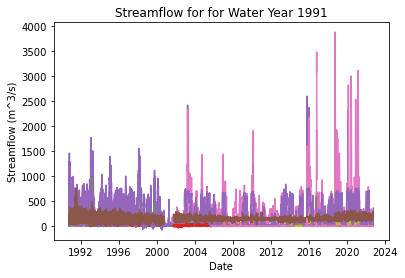

In [22]:
# Transpose and format observations dates
df_plot = site_df.drop(columns=['site_id', 'num_obs']).T
df_plot.index = pd.to_datetime(df_plot.index)

# Plot
plt.plot(df_plot)
plt.xlabel('Date')
plt.ylabel('Streamflow (m^3/s)')
plt.title(f'Streamflow for for Water Year 1991')

site_names = metadata_df['site_name']
#plt.legend(site_names)
plt.show()

Here I see that I have enough data for streamflow in my watershed for future class projects.

For my ET calculation, I will choose summer days during which there is no precipitation. I use the USDA dataset to find 2 days in the summer (2020-08-26 : 2020-08-28) that have no precipitation in my watershed.

In [73]:
# Looking at precipitation during the summer
# trying to find 2 consecutive days with no precipitation.
# I will also plot the point on the map where USDA measurements (including soil moisture) are made
date_start = '2020-08-26'
date_end = '2020-08-28'
latitude_range = (32, 34.5)
longitude_range = (-81, -78.5)


precip_df, metadata_df = point_obs.get_pandas_observations(data_source='usda_nrcs', variable='precipitation', 
                                                    temporal_resolution='daily', aggregation='total', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True)

collecting data...
data collected.


In [74]:
# Calculate and add mercator coordinates to metadata DataFrame
metadata_df['x'] = metadata_df.apply(lambda x: wgs84_to_web_mercator(x['longitude'], x['latitude'])[0], axis=1)
metadata_df['y'] = metadata_df.apply(lambda x: wgs84_to_web_mercator(x['longitude'], x['latitude'])[1], axis=1)

In [75]:
# Plot location of USDA dataset
from bokeh.plotting import figure, output_notebook, show
from bokeh.tile_providers import OSM, get_provider
from bokeh.models import ColumnDataSource

output_notebook()
tile_provider = get_provider(OSM)

# Range bounds supplied in web mercator coordinates
# Translate min and max bounding values from metadata
p = figure(x_range=(wgs84_to_web_mercator(longitude_range[1], latitude_range[1])[0], 
                    wgs84_to_web_mercator(longitude_range[0], latitude_range[0])[0]),
           y_range=(wgs84_to_web_mercator(longitude_range[0], latitude_range[0])[1], 
                    wgs84_to_web_mercator(longitude_range[1], latitude_range[1])[1]),
           x_axis_type="mercator", y_axis_type="mercator")
p.add_tile(tile_provider)

# Define data source for point overlays
source = ColumnDataSource(
    data=dict(x=list(metadata_df['x']),
              y=list(metadata_df['y']))
)

# Overlay red circles onto map for site locations
p.circle(x="x", y="y", size=15, fill_color="red", fill_alpha=0.8, source=source)

show(p)

Loading BokehJS ...

I do observe that soil moisture measurements are taken a few miles away from the AmeriFlux tower. This might slightly bias my results, but it is still a ballpark estimate of soil parameters in a marshy region.

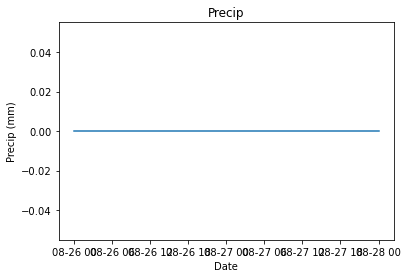

In [76]:
# Plotting precipitation during my 2 days of interest
# we observe no precipitation during my 2 days of study
df_plot = precip_df.drop(columns=['site_id', 'num_obs']).T
df_plot.index = pd.to_datetime(df_plot.index)

# Plot
plt.plot(df_plot)
plt.xlabel('Date')
plt.ylabel('Precip (mm)')
plt.title(f'Precip')

site_names = metadata_df['site_name']
#plt.legend(site_names)
plt.show()

In [2]:
# Collect variables for my ET calculations during my desired days
date_start = '2020-08-26'
date_end = '2020-08-28'
latitude_range = (32, 34)
longitude_range = (-80, -77)


temp_df, metadata_df = point_obs.get_pandas_observations(data_source='ameriflux', variable='temperature', 
                                                    temporal_resolution='hourly', aggregation='average', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True, site_ids=['US-HB1'])

windspeed_df, metadata_df = point_obs.get_pandas_observations(data_source='ameriflux', variable='wind speed', 
                                                    temporal_resolution='hourly', aggregation='average', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True, site_ids=['US-HB1'])

vpdef_df, metadata_df = point_obs.get_pandas_observations(data_source='ameriflux', variable='vapor pressure deficit', 
                                                    temporal_resolution='hourly', aggregation='average', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True, site_ids=['US-HB1'])

lwrad_df, metadata_df = point_obs.get_pandas_observations(data_source='ameriflux', variable='longwave radiation', 
                                                    temporal_resolution='hourly', aggregation='average', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True, site_ids=['US-HB1'])

swrad_df, metadata_df = point_obs.get_pandas_observations(data_source='ameriflux', variable='shortwave radiation', 
                                                    temporal_resolution='hourly', aggregation='average', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True, site_ids=['US-HB1'])

sensible_df, metadata_df = point_obs.get_pandas_observations(data_source='ameriflux', variable='sensible heat flux', 
                                                    temporal_resolution='hourly', aggregation='total', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True, site_ids=['US-HB1'])

latent_df, metadata_df = point_obs.get_pandas_observations(data_source='ameriflux', variable='latent heat flux', 
                                                    temporal_resolution='hourly', aggregation='total', 
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True, site_ids=['US-HB1'])

collecting data...
data collected.
collecting data...
data collected.
collecting data...
data collected.
collecting data...
data collected.
collecting data...
data collected.
collecting data...
data collected.
collecting data...
data collected.


### Calculating 'ground truth' in ET
Here I calculate the observed ET during my 2 days of study. I do so by dividing Latent heat flux by the heat of vaporization of water

In [5]:
E_array = []

for i in range(len(data_df_Penman)):
    LE = data_df_Penman['LE'].iloc[i]
    Vap = 2.45e6 # J/Kg
    
    # E
    E = LE/Vap/100 # units are m/s (dividing by 100 to convert)
    E_array.append(E)
    

## Plot some data during the days of interest
Below I plot AmeriFlux tower data during my 2 days of interest

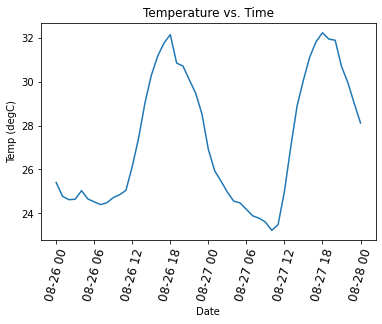

In [6]:
# plot temperature 

# Transpose and format observations dates
df_plot = temp_df.drop(columns=['site_id', 'num_obs']).T
df_plot.index = pd.to_datetime(df_plot.index)

# Plot
plt.plot(df_plot)
plt.xlabel('Date')
plt.ylabel('Temp (degC)')
plt.title(f'Temperature vs. Time')
plt.tick_params(axis='x', which='major', labelsize=12)
plt.xticks(rotation=75)
site_names = metadata_df['site_name']
#plt.legend(site_names)
plt.show()

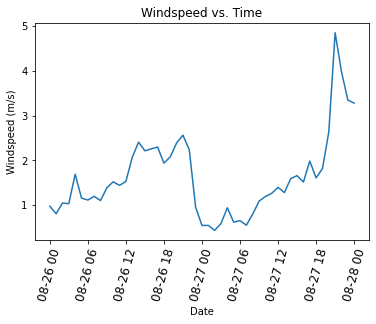

In [7]:
# plot windspeed

# Transpose and format observations dates
df_plot = windspeed_df.drop(columns=['site_id', 'num_obs']).T
df_plot.index = pd.to_datetime(df_plot.index)

# Plot
plt.plot(df_plot)
plt.xlabel('Date')
plt.ylabel('Windspeed (m/s)')
plt.title(f'Windspeed vs. Time')
plt.tick_params(axis='x', which='major', labelsize=12)
plt.xticks(rotation=75)
site_names = metadata_df['site_name']
#plt.legend(site_names)
plt.show()

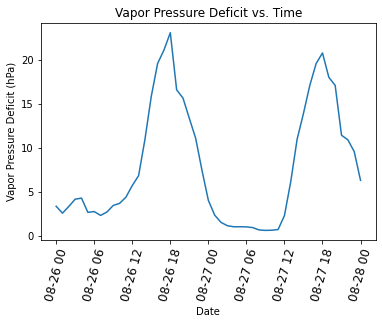

In [8]:
# plot vapor pressure deficit

# Transpose and format observations dates
df_plot = vpdef_df.drop(columns=['site_id', 'num_obs']).T
df_plot.index = pd.to_datetime(df_plot.index)

# Plot
plt.plot(df_plot)
plt.xlabel('Date')
plt.ylabel('Vapor Pressure Deficit (hPa)')
plt.title(f'Vapor Pressure Deficit vs. Time')
plt.tick_params(axis='x', which='major', labelsize=12)
plt.xticks(rotation=75)
site_names = metadata_df['site_name']
#plt.legend(site_names)
plt.show()

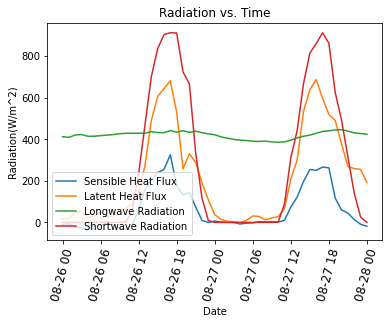

In [9]:
# plot Radiation budget 

# Transpose and format observations dates
lwdf_plot = lwrad_df.drop(columns=['site_id', 'num_obs']).T
lwdf_plot.index = pd.to_datetime(lwdf_plot.index)

# Transpose and format observations dates
swdf_plot = swrad_df.drop(columns=['site_id', 'num_obs']).T
swdf_plot.index = pd.to_datetime(swdf_plot.index)

# Transpose and format observations dates
sensible_plot = sensible_df.drop(columns=['site_id', 'num_obs']).T
sensible_plot.index = pd.to_datetime(sensible_plot.index)

# Transpose and format observations dates
latent_plot = latent_df.drop(columns=['site_id', 'num_obs']).T
latent_plot.index = pd.to_datetime(latent_plot.index)

# Plot
plt.plot(sensible_plot, label = "Sensible Heat Flux")
plt.plot(latent_plot, label = 'Latent Heat Flux')

# Plot
plt.plot(lwdf_plot, label = "Longwave Radiation")
plt.plot(swdf_plot, label = 'Shortwave Radiation')
plt.xlabel('Date')
plt.ylabel('Radiation(W/m^2)')
plt.title(f'Radiation vs. Time')
plt.tick_params(axis='x', which='major', labelsize=12)
plt.xticks(rotation=75)
site_names = metadata_df['site_name']
plt.legend(loc='lower left')
plt.show()

## Begin my ET calculation using mean variables
Here I use the following equations to calculate ET (from Dingman 7-1):

$$ E = K_e*u_a*(e_s - e_a)$$ 

$$K_e = \frac{0.622*\rho_a}{P*\rho_w}*\frac{k^2}{\left[ln\left(\frac{z_m-z_d}{z_0} \right)  \right]^2}$$

Where $e_s - e_a$ is the pressure deficit that is given to us in the AmeriFlux tower

In [10]:
# constants and functions

k = 0.4          # von Karman constant
rho_air = 1.2    # kg/m^3 density of air
rho_water = 997  # kg/m^2
zm = 30          # z values from figure 5 of https://www.mdpi.com/2306-5729/5/4/97
zd = 24
z0 = 2.1
P = 101300       # air pressure in Pa

# calculate Ke
Ke = ((.622*rho_air)/(P*rho_water))*(k**2)/(np.log((zm-zd)/z0))**2 

# mean variables equation
def E_mean_variables(VA, KE, PRESDEF):
    return KE*VA*PRESDEF


In [11]:
# Setting up data to calculate ET using mean variables

temp = temp_df.drop(columns=['site_id', 'num_obs']).T
windspeed = windspeed_df.drop(columns=['site_id', 'num_obs']).T
vpdef = vpdef_df.drop(columns=['site_id', 'num_obs']).T
data_df = pd.concat([temp, windspeed, vpdef], axis=1)
data_df.columns = ["Ta", "Va", "P_def"]
data_df.head(10)

,Ta,Va,P_def
2020-08-26 00:00:00,25.408379,0.974106,3.348101
2020-08-26 01:00:00,24.775742,0.804659,2.568064
2020-08-26 02:00:00,24.622208,1.044050,3.337106
2020-08-26 03:00:00,24.640853,1.030058,4.154766
2020-08-26 04:00:00,25.032307,1.688715,4.274482
2020-08-26 05:00:00,24.655166,1.155670,2.657779
2020-08-26 06:00:00,24.523964,1.110825,2.747861
2020-08-26 07:00:00,24.398042,1.193097,2.312986
2020-08-26 08:00:00,24.483211,1.100216,2.691614
2020-08-26 09:00:00,24.714609,1.385680,3.442118


In [12]:
# Calculating ET for each hour in m/s

# array of evaporation for each out
E_array_mean_variables = []

# calculations for each hour
for i in range(len(data_df)):
    Va = data_df['Va'].iloc[i] # m/s
    Pdef = data_df['P_def'].iloc[i]*100 # convert to Pa

    # E
    E = E_mean_variables(Va, Ke, Pdef)
    E_array_mean_variables.append(E)

## Calculating ET using Penman
Here I use the following equation to calculate ET from [FAO-56](https://www.fao.org/3/x0490e/x0490e00.htm#Contents)

Variables needed:
1. Net radiation (longwave & shortwave) via a theoretical solar radiation budget
2. Vapor pressure values
3. Slope of vapor pressure curve, $\Delta$
4. Psychometric constant, $\gamma$

$$ ET_0 = \frac{0.408\Delta(R_n-G)+\gamma\frac{900}{T+273}u_2(e_s-e_a)}{\Delta+\gamma(1+0.34u_2)} $$

Here $e_s-e_a$ is the pressure deficit given to us in the AmeriFlux tower. $R_n$ is the net radiation (adding shortwave + longwave from the AmeriFlux tower).

In [13]:
# Organize data for Penman

temp = temp_df.drop(columns=['site_id', 'num_obs']).T
windspeed = windspeed_df.drop(columns=['site_id', 'num_obs']).T
vpdef = vpdef_df.drop(columns=['site_id', 'num_obs']).T
lwrad = lwrad_df.drop(columns=['site_id', 'num_obs']).T
swrad = swrad_df.drop(columns=['site_id', 'num_obs']).T
sensible = sensible_df.drop(columns=['site_id', 'num_obs']).T
latent = latent_df.drop(columns=['site_id', 'num_obs']).T

data_df_Penman = pd.concat([temp, windspeed, vpdef,lwrad,swrad,sensible,latent], axis=1)
data_df_Penman.columns = ["Ta", "Va", "P_def","L","K","H","LE"]
data_df_Penman.head(5)

,Ta,Va,P_def,L,K,H,LE
2020-08-26 00:00:00,25.408379,0.974106,3.348101,411.807522,0.0,-10.718970,18.31656
2020-08-26 01:00:00,24.775742,0.804659,2.568064,408.591228,0.0,-7.844394,20.40769
2020-08-26 02:00:00,24.622208,1.044050,3.337106,419.887422,0.0,-22.746500,46.21980
2020-08-26 03:00:00,24.640853,1.030058,4.154766,422.389860,0.0,-25.736240,50.76900
2020-08-26 04:00:00,25.032307,1.688715,4.274482,413.674572,0.0,-38.405800,22.61419


## Functions to calculate necessary variables 

Here I use the following equations for the Penman equation:

Delta: derivative of saturation vapor pressure as a function of temperature. $\Delta$ in units of $\text{kPa C}^{-1}$
$$\Delta = 4096\frac{0.6108 exp\bigg[\frac{17.27T}{T+237.3}\bigg]}{(T+237.3)^2}$$


The psychrometric constant is thus given by
$$\gamma = \frac{c_a p}{\varepsilon \lambda_v}$$

It includes the following variables:
- the heat capacity of air, $c_a$
- atmospheric pressure, $p$
- latent heat of vaporization, $\lambda_v$
- the ratio of the molecular weight of water vapor to dry air, $\varepsilon=0.622$

In [16]:
# delta kPa/C
def DELTA(T):
    return 4096*(0.6108*np.exp(17.27*T/(T+237.3)))/(T + 237.3)**2 

# calculating Gamma, since it is a constant
c_a = 10e-3        # specific heat capacity of air [MJ/(kg*K)]
p = 101.3          # atmospheric pressure [kPa]
lv = 2.47          # latent heat of vaporization [MJ/kg]
epsilon = 0.622    # ratio of the molecular weight of water vapor to dry air

# calculate psychometric constant
gamma = c_a*p/(epsilon*lv)

# penman
def PENMAN(DELTA,RN,GAMMA,T,U,PDEF):
    return (0.408*DELTA*RN+GAMMA*(900/(T+273))*U*(PDEF))/(DELTA+GAMMA*(1+0.34*U)) # in mm/day

In [17]:
# calculating Penman ET hourly

# array of evaporation for each out
E_array_Penman = []

# calculations for each hour
for i in range(len(data_df)):
    Ta = data_df_Penman['Ta'].iloc[i]
    Va = data_df_Penman['Va'].iloc[i]
    Pdef = data_df_Penman['P_def'].iloc[i]*100 # convert to Pa
    L = data_df_Penman['L'].iloc[i]
    k = data_df_Penman['K'].iloc[i]
    l = data_df_Penman['H'].iloc[i]
    LE = data_df_Penman['LE'].iloc[i]
    
    Rn = (L + k) * 0.0864  # Rn in MJ/m^2 day
    Pdef = Pdef / 10       # Pdef in kPa
    delta = DELTA(Ta)      # calculate delta
    u = Va                 # wind m/s
    
     
    E_Penman = PENMAN(delta,Rn,gamma,Ta,u,Pdef)
    E_Penman_m_s = E_Penman*1.15741e-8   # convert to m/s
    E_array_Penman.append(E_Penman_m_s)


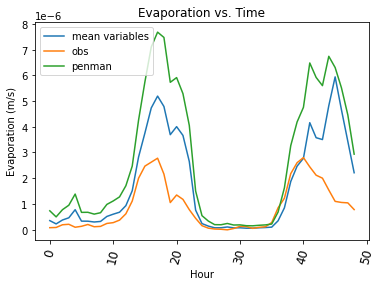

In [18]:
# Compare both methods to ground truth

plt.plot(E_array_mean_variables, label = "mean variables")
plt.plot(E_array, label='obs')
plt.plot(E_array_Penman, label = "penman")
plt.xlabel('Hour')
plt.ylabel('Evaporation (m/s)')
plt.title(f'Evaporation vs. Time')
plt.tick_params(axis='x', which='major', labelsize=12)
plt.xticks(rotation=75)

plt.legend()

## Calculating daily average values of ET

In [19]:
# average daily values from AmeriFlux tower

# temperature
temp_day1 = data_df_Penman['Ta'].loc['2020-08-26':'2020-08-27']
Ta1 = temp_day1.mean()
temp_day2 = data_df_Penman['Ta'].loc['2020-08-27':'2020-08-28']
Ta2 = temp_day2.mean()

# windspeed
wind_day1 = data_df_Penman['Va'].loc['2020-08-26':'2020-08-27']
Va1 = wind_day1.mean()
wind_day2 = data_df_Penman['Va'].loc['2020-08-27':'2020-08-28']
Va2 = wind_day2.mean()

# P_Def
Pdef_day1 = data_df_Penman['P_def'].loc['2020-08-26':'2020-08-27']
Pdef1 = Pdef_day1.mean()
Pdef_day2 = data_df_Penman['P_def'].loc['2020-08-27':'2020-08-28']
Pdef2 = Pdef_day2.mean()

# Longwave radiation
L_day1 = data_df_Penman['L'].loc['2020-08-26':'2020-08-27']
L1 = L_day1.mean()
L_day2 = data_df_Penman['L'].loc['2020-08-27':'2020-08-28']
L2 = L_day2.mean()

# Shortwave radiation
K_day1 = data_df_Penman['K'].loc['2020-08-26':'2020-08-27']
K1 = K_day1.mean()
K_day2 = data_df_Penman['K'].loc['2020-08-27':'2020-08-28']
K2 = K_day2.mean()

# Shortwave radiation
K_day1 = data_df_Penman['K'].loc['2020-08-26':'2020-08-27']
K1 = K_day1.mean()
K_day2 = data_df_Penman['K'].loc['2020-08-27':'2020-08-28']
K2 = K_day2.mean()

# Sensible heat
H_day1 = data_df_Penman['H'].loc['2020-08-26':'2020-08-27']
H1 = H_day1.mean()
H_day2 = data_df_Penman['H'].loc['2020-08-27':'2020-08-28']
H2 = H_day2.mean()

# Latent heat
LE_day1 = data_df_Penman['LE'].loc['2020-08-26':'2020-08-27']
LE1 = LE_day1.mean()
LE_day2 = data_df_Penman['LE'].loc['2020-08-27':'2020-08-28']
LE2 = LE_day2.mean()


In [23]:
# Day 1, calculating ET using daily average values

# ------ ground truth ---------
Vap = 2.45e6 # J/Kg
E_day1 = LE1/Vap/100 # units are m/s (dividing by 100 to convert)

# ------ mean variables --------
E_mv1 = E_mean_variables(Va1, Ke, Pdef1) # in m/s

# ------ Penman --------
Rn1 = (L1 + K1)* 0.0864  # Rn in MJ/m^2 day
Pdef1 = Pdef1 / 10       # Pdef in kPa
delta1 = DELTA(Ta1)      # calculate delta
u1 = Va1                 # wind m/s
    
E_Penman1 = PENMAN(delta1,Rn1,gamma,Ta1,u1,Pdef1)
E_Penman1_m_s = E_Penman1*1.15741e-8   # convert to m/s

print(f'The observed daily average ET for 08/26 is {E_day1: .2E} m/s')
print(f'The mean variable calculated daily average ET for 08/26 is {E_mv1: .2E} m/s')
print(f'The Penman calculated daily average ET for 08/26 is {E_Penman1_m_s: .2E} m/s')

The observed daily average ET for 08/26 is  8.60E-07 m/s
The mean variable calculated daily average ET for 08/26 is  1.51E-10 m/s
The Penman calculated daily average ET for 08/26 is  5.00E-08 m/s


In [44]:
# Day 2, calculating ET using daily average values

# ------ ground truth ---------
Vap = 2.45e6 # J/Kg
E_day2 = LE2/Vap/100 # units are m/s (dividing by 100 to convert)

# ------ mean variables --------
E_mv2 = E_mean_variables(Va2, Ke, Pdef2) # in m/s

# ------ Penman --------
Rn2 = (L2 + K2)* 0.0864  # Rn in MJ/m^2 day
Pdef2 = Pdef2 / 10       # Pdef in kPa
delta2 = DELTA(Ta2)      # calculate delta
u2 = Va2                 # wind m/s
    
E_Penman2 = PENMAN(delta2,Rn2,gamma,Ta2,u2,Pdef2)
E_Penman2_m_s = E_Penman2*1.15741e-8   # convert to m/s

print(f'The observed daily average ET for 08/26 is {E_day2: .2E} m/s')
print(f'The mean variable calculated daily average ET for 08/26 is {E_mv2: .2E} m/s')
print(f'The Penman calculated daily average ET for 08/26 is {E_Penman2_m_s: .2E} m/s')

The observed daily average ET for 08/26 is  9.16E-07 m/s
The mean variable calculated daily average ET for 08/26 is  1.19E-08 m/s
The Penman calculated daily average ET for 08/26 is  6.95E-08 m/s


## Using observed soil moisture nearby to determine a beta approximation for soil evap

I use the observed daily soil moisture value to modify preducted ET from mean variables and Penman

In [43]:
# getting soil moisture to find Beta term
date_start = '2020-08-26'
date_end = '2020-08-28'
latitude_range = (32, 34.5)
longitude_range = (-81, -78.5)


soil_df, metadata_df = point_obs.get_pandas_observations(data_source='usda_nrcs', variable='soil moisture', 
                                                    temporal_resolution='daily', aggregation='start-of-day', depth_level=2,
                                                    date_start=date_start, date_end=date_end,
                                                    latitude_range=latitude_range, longitude_range=longitude_range,
                                                    return_metadata=True, all_attributes=True)

collecting data...
data collected.


In [44]:
soil_df


,site_id,2020-08-26,2020-08-27,2020-08-28,num_obs
0,2037:SC:SCAN,19.3,16.9,15.2,3


I will use a 19.3% soil moisture percentage for the first day of my data and a 16.9% soil moisture percentage forth second day to modify my calculated ET values

In [76]:
# setting up beta approximation
w0=40 # assuming I don't need a high w0 value since the land is a brackish marsh
wc=5  # these values are also fit empirically

beta_soil1 = (19.3-wc)/(w0-wc)
beta_soil2= (16.9-wc)/(w0-wc)

# creating new arrays for modified E values
E_mv_soil = []
E_Penman_soil = []

# multiply our initially calculated ET estimation by Beta
for i in range(len(E_array_mean_variables)):
    # for the first day, use day 1 soil moisture beta
    if i <= (len(E_array_mean_variables) + 1)/2:
        E_mv = beta_soil1*E_array_mean_variables[i]
        E_Penman = beta_soil1*E_array_Penman[i]
        
    else:
        E_mv = beta_soil2*E_array_mean_variables[i]
        E_Penman = beta_soil1*E_array_Penman[i]
    
    E_mv_soil.append(E_mv)
    E_Penman_soil.append(E_Penman)

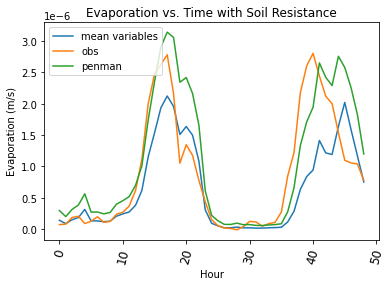

In [80]:
# Compare both methods using soil resistance to ground truth

plt.plot(E_mv_soil, label = "mean variables")
plt.plot(E_array, label='obs')
plt.plot(E_Penman_soil, label = "penman")
plt.xlabel('Hour')
plt.ylabel('Evaporation (m/s)')
plt.title(f'Evaporation vs. Time with Soil Resistance')
plt.tick_params(axis='x', which='major', labelsize=12)
plt.xticks(rotation=75)

plt.legend()

## Using an approximate stomatal resistance to determine a beta approximation

I empirically find a stomatal resistance term and reference the following paper: https://bg.copernicus.org/articles/15/3277/2018/bg-15-3277-2018.pdf


In [101]:
Rs = 2.4 
beta_stomatal = 1/Rs

# creating new arrays for modified E values
E_mv_leaf = []
E_Penman_leaf = []

# multiply our initially calculated ET estimation by Beta
for i in range(len(E_array_mean_variables)):
    
    E_mv = beta_stomatal*E_array_mean_variables[i]
    E_Penman = beta_stomatal*E_array_Penman[i]
    
    E_mv_leaf.append(E_mv)
    E_Penman_leaf.append(E_Penman)

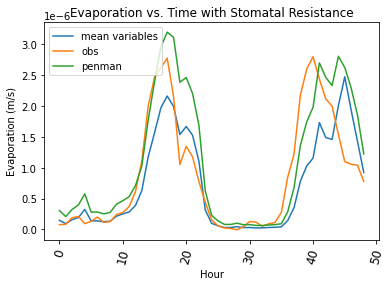

In [102]:
# Compare both methods using stomatal resistance to ground truth

plt.plot(E_mv_leaf, label = "mean variables")
plt.plot(E_array, label='obs')
plt.plot(E_Penman_leaf, label = "penman")
plt.xlabel('Hour')
plt.ylabel('Evaporation (m/s)')
plt.title(f'Evaporation vs. Time with Stomatal Resistance')
plt.tick_params(axis='x', which='major', labelsize=12)
plt.xticks(rotation=75)

plt.legend()

## Discussion

- Using hourly Penman and Mean variables methods without any resistance terms: As expected, I find that the mean variables approach and the Penman equation overestimate ET in comparison to the measurements from the AmeriFlux tower. I was, however, still impressed that both methods really captured the changes in evaporation over time throughout the 2 days of interest. For example, both methods capture a peak in ET around hour 15 and a dip in ET around hour 18. Interestingly, the Penman equation estimate for ET is farther from the ground truth than the mean variables approach. This emphasizes that a more complicated method does not necessarily yield more accurate results.
- Using daily Penman and Mean variables methods without any resistance terms: As expected, my estimates for ET with both methods using daily averaged data varied much more from the ground truth than the hourly data. Interestingly, the error between the estimated ET and ground truth ET was much higher on day 1 versus day 2. Perhaps this had something to do with the large variations in ET between hours 15-20 of day 1. Although inaccurate, the day 2 daily averaged values were still roughly the same order of magnitude as the observed ET. It also appears that the hourly values for day 1 are more accurate than the hourly values for day 2 and the daily values for day 2 are more accurate than the daily values for day 1.
- Soil resistance and stomatal resistance: to me, these approaches felt very ad-hoc. I empirically fit the beta values for both resistance terms to minimize error. I can see how adding a resistance term can get very complicated; even though I tried to pick a beta that minimizes error, we still observe differences between the ground truth and calculated values for the 2 methods. 